## Predicción de Series Temporales con MLP
### Caso: Cotización USD/BRL (2015 - 2026)

**Objetivo:** Predecir el tipo de cambio diario aplicando redes neuronales sobre datos históricos.

**Estructura del Proyecto:**
1. **Preprocesamiento:** Limpieza, ventanas deslizantes y normalización.
2. **Modelado (PyTorch):** Modelo *Naive* (línea base), MLP Simple y MLP Profundo.
3. **Resultados:** Comparación de métricas y conclusiones.

#### 1. Importación de Librerías
* **Herramientas:** PyTorch (Deep Learning), Pandas, NumPy, Scikit-learn y Matplotlib.
* **Reproducibilidad:** Semillas aleatorias fijadas.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

# Semilla para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)

print('Librerías cargadas correctamente.')
print(f'PyTorch versión: {torch.__version__}')

Librerías cargadas correctamente.
PyTorch versión: 2.5.1


#### 2. Carga y Preprocesamiento del Dataset
* **Origen:** Investing.com (Cotización diaria USD/BRL).
* **Ajustes realizados:**
  * **Inversión cronológica** (para que la red lea del pasado al futuro).
  * **Filtrado:** Conservamos solo `Date` y `Price`.
  * **Conversión:** Transformación de `Price` a valor numérico.

In [28]:
# ── Ajusta esta ruta si es necesario ──────────────────────────────────────────
ruta_csv = r'D:\2026\IA-2026-DATASETS\USD_BRL Historical Data.csv'
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(ruta_csv)

# Conservar solo Fecha y Precio de Cierre
df = df[['Date', 'Price']]

# Convertir la columna Date a formato datetime de Pandas
df['Date'] = pd.to_datetime(df['Date'])

# Ordenar cronológicamente: del registro más antiguo al más reciente
df = df.sort_values('Date').reset_index(drop=True)

# Garantizar que Price sea de tipo numérico
if df['Price'].dtype == 'object':
    df['Price'] = df['Price'].str.replace(',', '').astype(float)

print('Tamaño del dataset:', df.shape)
print(df.head())
print('\nRango de fechas:', df['Date'].min(), '→', df['Date'].max())

Tamaño del dataset: (2922, 2)
        Date   Price
0 2015-01-01  2.6570
1 2015-01-02  2.6931
2 2015-01-05  2.7059
3 2015-01-06  2.6996
4 2015-01-07  2.6830

Rango de fechas: 2015-01-01 00:00:00 → 2026-03-13 00:00:00


#### 3. Evolución Histórica USD/BRL
* **Análisis Visual:** Tendencia alcista (desde 2015), pico de volatilidad (2020) y régimen de alta oscilación (4.5 - 6.0 BRL).
* **Justificación del Modelo:** La complejidad y no linealidad de estos datos exigen el uso de Redes Neuronales.

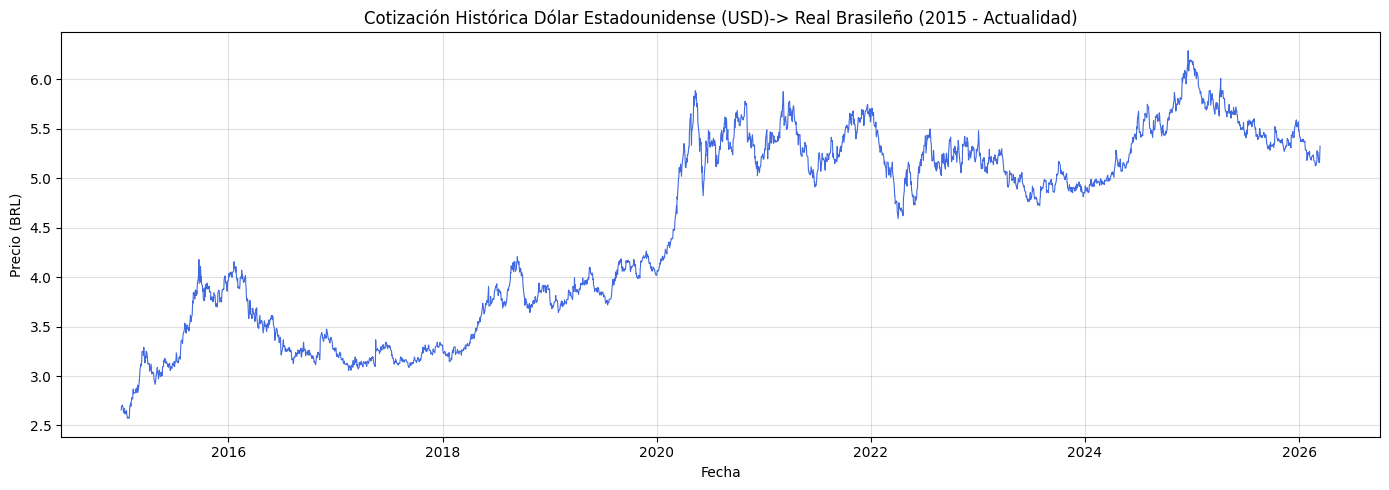

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Price'], color='royalblue', linewidth=0.8)
plt.title('Cotización Histórica Dólar Estadounidense (USD)-> Real Brasileño (2015 - Actualidad)')
plt.xlabel('Fecha')
plt.ylabel('Precio (BRL)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

#### 4. Ingeniería de Características
* **Ventanas Deslizantes:** Transformación de la serie temporal continua en ventanas de tamaño fijo (regresión supervisada). 
  * *Enfoque:* Usar los últimos **50 días** para predecir el **día 51**.
* **Normalización (Min-Max):** Escalamiento de datos al rango `[0, 1]`. Fundamental para estabilizar los gradientes y acelerar la convergencia de la red.

In [30]:
# ── Hiperparámetro: longitud de la ventana ────────────────────────────────────
n_steps = 50   # usamos los últimos 50 días para predecir el día 51
# ─────────────────────────────────────────────────────────────────────────────

# Normalización Min-Max al rango [0, 1]
precios = df['Price'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
precios_norm = scaler.fit_transform(precios).flatten()

# Construcción de ventanas deslizantes
def crear_ventanas(serie, n_steps):
    """Convierte una serie 1D en pares (X_ventana, y_siguiente)."""
    X, y = [], []
    for i in range(len(serie) - n_steps):
        X.append(serie[i : i + n_steps])
        y.append(serie[i + n_steps])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32).reshape(-1, 1)

X_all, y_all = crear_ventanas(precios_norm, n_steps)
print(f'Total de muestras generadas: {len(X_all)}')
print(f'Forma de X_all: {X_all.shape}   → (muestras, n_steps)')
print(f'Forma de y_all: {y_all.shape}  → (muestras, 1)')

Total de muestras generadas: 2872
Forma de X_all: (2872, 50)   → (muestras, n_steps)
Forma de y_all: (2872, 1)  → (muestras, 1)


#### 5. División del Dataset
* **Proporciones:** 70% Entrenamiento / 15% Validación / 15% Prueba.
* **Restricción Clave:** División estrictamente **cronológica** (sin mezcla aleatoria). 
* **Justificación:** Evitar la "fuga de datos" (que el modelo vea información del futuro durante el entrenamiento).

In [31]:
# División cronológica Train / Validación / Test  (70% / 15% / 15%)
n_total  = len(X_all)
n_train  = int(n_total * 0.70)
n_val    = int(n_total * 0.15)

X_train, y_train = X_all[:n_train],               y_all[:n_train]
X_valid, y_valid = X_all[n_train:n_train+n_val],  y_all[n_train:n_train+n_val]
X_test,  y_test  = X_all[n_train+n_val:],         y_all[n_train+n_val:]

print(f'Train : {X_train.shape[0]} muestras')
print(f'Valid : {X_valid.shape[0]} muestras')
print(f'Test  : {X_test.shape[0]}  muestras')

Train : 2010 muestras
Valid : 430 muestras
Test  : 432  muestras


In [ ]:
# ── Tensores de test para evaluación directa (sin DataLoader) ────────────────
# Necesarios para usar .cpu().numpy() y aplicar inverse_transform() correctamente
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

print(f'X_test_tensor : {X_test_tensor.shape}')
print(f'y_test_tensor : {y_test_tensor.shape}')

#### 6. Dataset y DataLoader en PyTorch
* **`Dataset`:** Encapsula los datos y define cómo acceder a cada muestra.
* **`DataLoader`:** Itera los datos en *batches* (lotes) para actualizar los pesos incrementalmente.
* **Configuración de Mezcla (*Shuffle*):**
  * **Entrenamiento:** `True` (evita que el modelo memorice el orden de los lotes).
  * **Validación/Prueba:** `False` (mantiene el orden real para evaluar correctamente las predicciones).

In [32]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y=None, train=True):
        self.X     = torch.tensor(X, dtype=torch.float32)
        self.y     = torch.tensor(y, dtype=torch.float32) if y is not None else None
        self.train = train

    def __len__(self):
        return len(self.X)

    def __getitem__(self, ix):
        if self.train and self.y is not None:
            return self.X[ix], self.y[ix]
        return self.X[ix]


dataset = {
    'train': TimeSeriesDataset(X_train, y_train, train=True),
    'eval' : TimeSeriesDataset(X_valid, y_valid, train=True),
    'test' : TimeSeriesDataset(X_test,  y_test,  train=False),
}

dataloader = {
    'train': DataLoader(dataset['train'], shuffle=True,  batch_size=64),
    'eval' : DataLoader(dataset['eval'],  shuffle=False, batch_size=64),
    'test' : DataLoader(dataset['test'],  shuffle=False, batch_size=64),
}

print('DataLoaders creados correctamente.')
print(f'Batches por época (train): {len(dataloader["train"])}')

DataLoaders creados correctamente.
Batches por época (train): 32


#### 7. Pipeline de Entrenamiento y Evaluación
Funciones centrales (reutilizables para todos los modelos):

* **`fit` (Entrenamiento):** Ejecuta el ciclo por épocas (Forward, MSE, Backprop, optimizador Adam) y evalúa simultáneamente en validación.
* **`predict` (Inferencia):** Genera predicciones eficientemente, desactivando el cálculo de gradientes para ahorrar memoria.
* **`desnorm` (Desnormalización):** Revierte la escala `[0, 1]` a los precios reales originales.

In [33]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo de cómputo: {device}')


def fit(model, dataloader, epochs=30):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.MSELoss()
    bar = tqdm(range(1, epochs + 1))

    for epoch in bar:
        # ── Fase de entrenamiento ──────────────────────────────────────────────
        model.train()
        train_loss = []
        for batch in dataloader['train']:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss  = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())

        # ── Fase de validación ─────────────────────────────────────────────────
        model.eval()
        eval_loss = []
        with torch.no_grad():
            for batch in dataloader['eval']:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss  = criterion(y_hat, y)
                eval_loss.append(loss.item())

        bar.set_description(
            f'loss {np.mean(train_loss):.5f}  val_loss {np.mean(eval_loss):.5f}'
        )


def predict(model, dataloader):
    model.eval()
    with torch.no_grad():
        preds = torch.tensor([]).to(device)
        for batch in dataloader:
            X    = batch.to(device)
            pred = model(X)
            preds = torch.cat([preds, pred])
    return preds


def desnorm(arr):
    """Transforma predicciones del rango [0,1] de vuelta a BRL."""
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()


print('Funciones fit, predict y desnorm definidas correctamente.')

Dispositivo de cómputo: cuda
Funciones fit, predict y desnorm definidas correctamente.


#### 5. Predicción *Naive* (Línea Base)
* **Propósito:** Establecer un punto de referencia mínimo. Si un modelo complejo no lo supera, no tiene utilidad práctica.
* **Lógica:** Predecir que el precio de mañana será exactamente igual al de hoy:
  $$\hat{y}(t+1) = y(t)$$
* **Contexto:** Muy competitivo en series financieras debido a que los precios suelen cambiar de forma gradual (alta autocorrelación).

MSE Naive (escala real BOB²): 0.001943


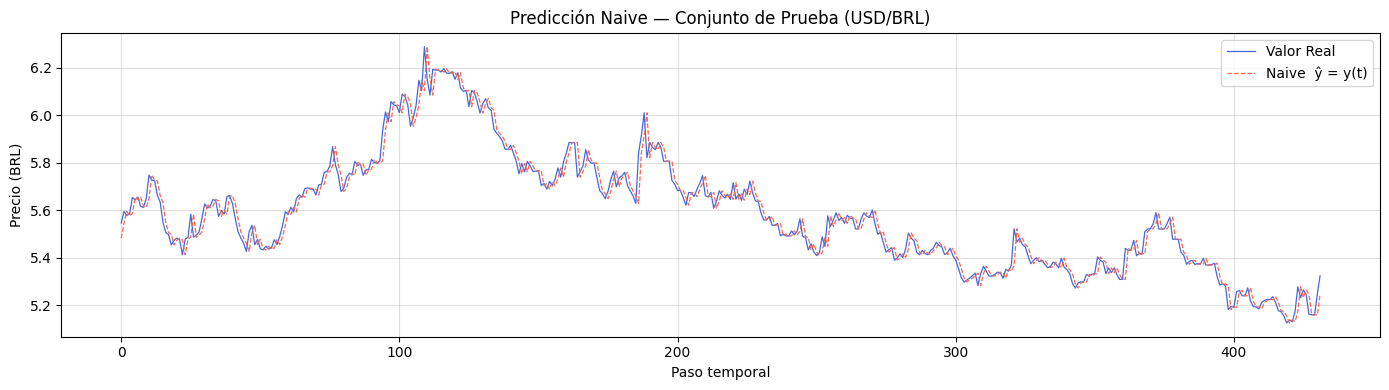

In [34]:
# El modelo Naive predice ŷ(t+1) = y(t)  →  último valor de cada ventana
y_pred_naive_norm = X_test[:, -1].reshape(-1, 1)

# ── Corrección de escala: inverse_transform → BRL ─────────────────────────────
y_test_real       = desnorm(y_test)
y_pred_naive_real = desnorm(y_pred_naive_norm)

# Métricas en BRL
mse_naive  = mean_squared_error(y_test_real, y_pred_naive_real)
rmse_naive = np.sqrt(mse_naive)
mae_naive  = np.mean(np.abs(y_test_real - y_pred_naive_real))

print(f'--- EVALUACIÓN NAIVE ---')
print(f'MSE  (Error Cuadrático Medio): {mse_naive:.4f}')
print(f'RMSE (Raíz del Error Cuad.):   {rmse_naive:.4f} BRL')
print(f'MAE  (Error Absoluto Medio):   {mae_naive:.4f} BRL')

plt.figure(figsize=(14, 4))
plt.plot(y_test_real,       label='Valor Real',       color='royalblue', linewidth=0.9)
plt.plot(y_pred_naive_real, label='Naive  ŷ = y(t)',  color='tomato',    linewidth=0.9, linestyle='--')
plt.title('Predicción Naive — Conjunto de Prueba (USD/BRL)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BRL)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

#### 6. Modelo MLP de Arquitectura Simple
* **Concepto:** Red neuronal completamente conectada (*feedforward*, sin retroalimentación).
* **Estructura Básica:** Conecta los 50 días de entrada directamente a una única neurona de salida.
* **Transformación Lineal:**
  $$\hat{y} = W \cdot x + b$$
* **Complejidad:** Solo **51 parámetros entrenables** (50 pesos + 1 sesgo).
* **Flujo del Modelo:**
  `Entrada (50) ──► Linear(50 → 1) ──► Salida (1)`

In [35]:
class MLPSimple(torch.nn.Module):
    """MLP de una sola capa lineal: 50 entradas → 1 salida."""
    def __init__(self, n_in=n_steps, n_out=1):
        super().__init__()
        self.fc = torch.nn.Linear(n_in, n_out)

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # aplanar el tensor de entrada
        return self.fc(x)


mlp_simple = MLPSimple()
print(mlp_simple)
total_params = sum(p.numel() for p in mlp_simple.parameters())
print(f'Parámetros entrenables: {total_params}')

MLPSimple(
  (fc): Linear(in_features=50, out_features=1, bias=True)
)
Parámetros entrenables: 51


In [36]:
fit(mlp_simple, dataloader, epochs=30)

loss 0.00068  val_loss 0.00040: 100%|██████████| 30/30 [00:02<00:00, 11.47it/s]


#### 7. Evaluación y Desnormalización
* **Inferencia:** Generación de predicciones sobre el conjunto de prueba.
* **Ajuste de Escala:** Desnormalización de los resultados al valor original (Reales) para una comparación exacta y real.

MSE MLP Simple (escala real BRL²): 0.006877


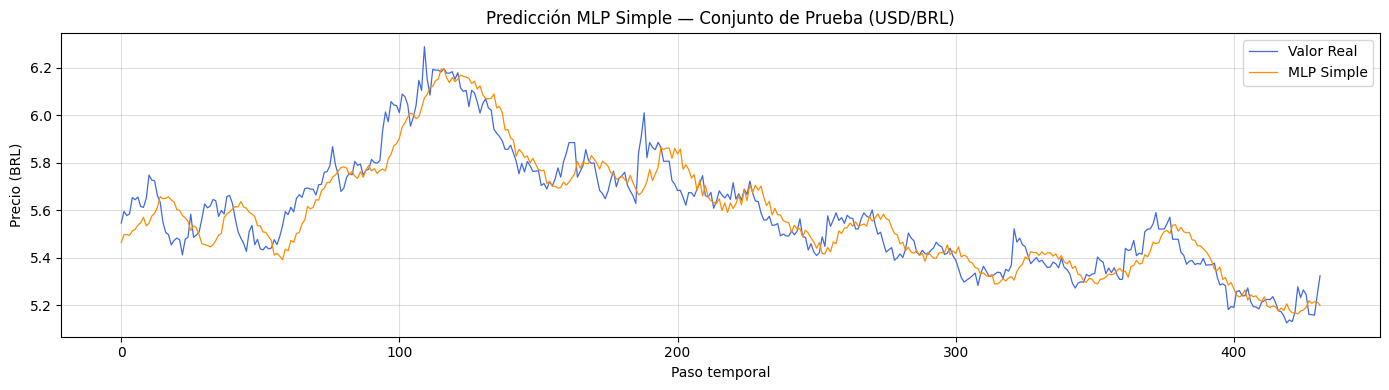

In [37]:
# ── 1. Predicción en modo evaluación (sin gradientes) ────────────────────────
mlp_simple.eval()
with torch.no_grad():
    y_pred_simple_escalado = mlp_simple(X_test_tensor)

# ── 2. Extraer a NumPy ────────────────────────────────────────────────────────
y_pred_simple_np = y_pred_simple_escalado.cpu().numpy()
y_test_np        = y_test_tensor.cpu().numpy()

# ── 3. DESNORMALIZACIÓN: inverse_transform → BRL ─────────────────────────────
y_pred_simple_real = scaler.inverse_transform(y_pred_simple_np)
y_test_real_2d     = scaler.inverse_transform(y_test_np)       # forma (N, 1)

# Versión 1D para gráficas y métricas (compatible con el resto del notebook)
y_pred_simple_real_1d = y_pred_simple_real.flatten()

# ── 4. Métricas en BRL ────────────────────────────────────────────────────────
mse_simple  = mean_squared_error(y_test_real_2d, y_pred_simple_real)
rmse_simple = np.sqrt(mse_simple)
mae_simple  = np.mean(np.abs(y_test_real_2d - y_pred_simple_real))

print('--- EVALUACIÓN FINAL: MLP SIMPLE ---')
print(f'MSE  (Error Cuadrático Medio): {mse_simple:.4f}')
print(f'RMSE (Raíz del Error Cuad.):   {rmse_simple:.4f} BRL')
print(f'MAE  (Error Absoluto Medio):   {mae_simple:.4f} BRL')

print('\nEjemplo de las primeras 5 predicciones (en BRL):')
for i in range(5):
    print(f'  Real: {y_test_real_2d[i][0]:.4f} | Predicción: {y_pred_simple_real[i][0]:.4f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_real,             label='Valor Real',   color='royalblue',  linewidth=0.9)
plt.plot(y_pred_simple_real_1d,   label='MLP Simple',   color='darkorange', linewidth=0.9)
plt.title('Predicción MLP Simple — Conjunto de Prueba (USD/BRL)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BRL)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

#### 8. Modelo MLP de Arquitectura Profunda
* **Objetivo:** Capturar patrones **no lineales** (tendencias, aceleraciones) que el modelo simple no puede detectar.
* **Componentes Clave:**
  * **Capas Ocultas (128 y 64 neuronas):** Mayor capacidad para aprender representaciones complejas.
  * **Activación ReLU:** Introduce la no linealidad necesaria.
  * **Dropout (20%):** Apaga neuronas aleatoriamente para evitar el sobreajuste (*overfitting*).

**Flujo de la Arquitectura:**
`Entrada (50) ──► [Linear(128) + ReLU + Dropout] ──► [Linear(64) + ReLU + Dropout] ──► Salida (1)`

In [38]:
class MLPMejorado(torch.nn.Module):
    """MLP profundo con capas ocultas, activación ReLU y Dropout."""
    def __init__(self, n_in=n_steps, n_out=1):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(n_in, 128),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(128, 64),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(64, n_out),
        )

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # aplanar el tensor de entrada
        return self.net(x)


mlp_mejor = MLPMejorado()
print(mlp_mejor)
total_params = sum(p.numel() for p in mlp_mejor.parameters())
print(f'Parámetros entrenables: {total_params}')

MLPMejorado(
  (net): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Parámetros entrenables: 14849


In [39]:
fit(mlp_mejor, dataloader, epochs=50)

loss 0.00180  val_loss 0.00032: 100%|██████████| 50/50 [00:05<00:00,  9.16it/s]


MSE MLP Mejorado (escala real BRL²): 0.006669


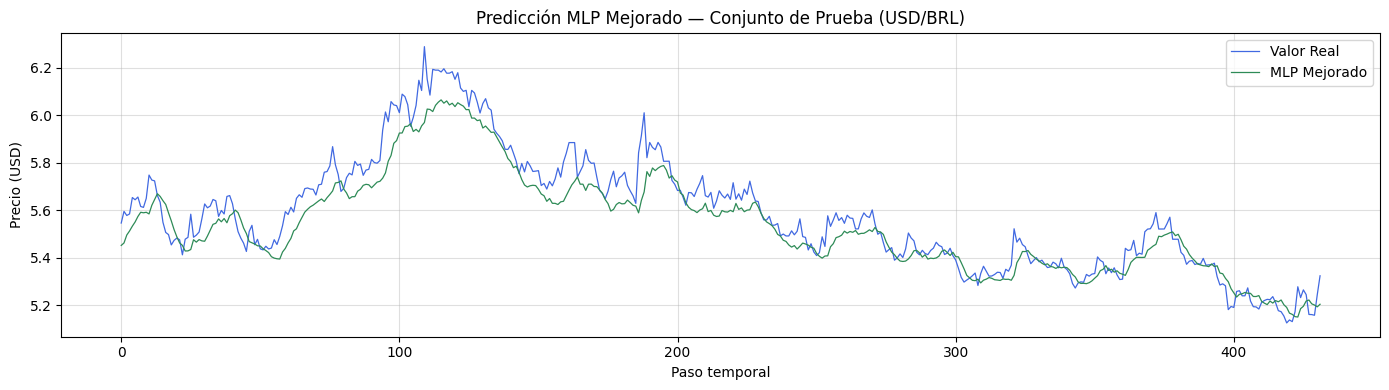

In [40]:
# ── 1. Predicción en modo evaluación (sin gradientes) ────────────────────────
mlp_mejor.eval()
with torch.no_grad():
    y_pred_mejor_escalado = mlp_mejor(X_test_tensor)

# ── 2. Extraer a NumPy ────────────────────────────────────────────────────────
y_pred_mejor_np = y_pred_mejor_escalado.cpu().numpy()

# ── 3. DESNORMALIZACIÓN: inverse_transform → BRL ─────────────────────────────
y_pred_mejor_real = scaler.inverse_transform(y_pred_mejor_np)

# Versión 1D para gráficas
y_pred_mejor_real_1d = y_pred_mejor_real.flatten()

# ── 4. Métricas en BRL ────────────────────────────────────────────────────────
mse_mejor  = mean_squared_error(y_test_real_2d, y_pred_mejor_real)
rmse_mejor = np.sqrt(mse_mejor)
mae_mejor  = np.mean(np.abs(y_test_real_2d - y_pred_mejor_real))

print('--- EVALUACIÓN FINAL: MLP MEJORADO ---')
print(f'MSE  (Error Cuadrático Medio): {mse_mejor:.4f}')
print(f'RMSE (Raíz del Error Cuad.):   {rmse_mejor:.4f} BRL')
print(f'MAE  (Error Absoluto Medio):   {mae_mejor:.4f} BRL')

print('\nEjemplo de las primeras 5 predicciones (en BRL):')
for i in range(5):
    print(f'  Real: {y_test_real_2d[i][0]:.4f} | Predicción: {y_pred_mejor_real[i][0]:.4f}')

plt.figure(figsize=(14, 4))
plt.plot(y_test_real,            label='Valor Real',    color='royalblue', linewidth=0.9)
plt.plot(y_pred_mejor_real_1d,   label='MLP Mejorado',  color='seagreen',  linewidth=0.9)
plt.title('Predicción MLP Mejorado — Conjunto de Prueba (USD/BRL)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BRL)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

#### 9. Comparación Final de Modelos
* **Métrica de Evaluación:** Error Cuadrático Medio (**MSE**) en la escala original (Reales²). *(A menor MSE, mayor precisión)*.
* **Análisis Visual:** Gráfica comparativa que superpone las predicciones de los 3 modelos (*Naive*, MLP Simple y MLP Profundo) sobre la serie real.

In [44]:
sep = '=' * 68
print(sep)
print(f'  {"TABLA COMPARATIVA FINAL — USD/BRL":^64}')
print(sep)
print(f'  {"Modelo":<18}  {"MSE (BRL²)":>12}  {"RMSE (BRL)":>12}  {"MAE (BRL)":>12}')
print('-' * 68)
print(f'  {"Naive  ŷ=y(t)":<18}  {mse_naive:>12.4f}  {rmse_naive:>12.4f}  {mae_naive:>12.4f}')
print(f'  {"MLP Simple":<18}  {mse_simple:>12.4f}  {rmse_simple:>12.4f}  {mae_simple:>12.4f}')
print(f'  {"MLP Mejorado":<18}  {mse_mejor:>12.4f}  {rmse_mejor:>12.4f}  {mae_mejor:>12.4f}')
print(sep)
ganador = min(
    [('Naive', rmse_naive), ('MLP Simple', rmse_simple), ('MLP Mejorado', rmse_mejor)],
    key=lambda x: x[1]
)
print(f'  Mejor RMSE: {ganador[0]}  ({ganador[1]:.4f} BRL)')
print(sep)

  Modelo              MSE (escala real BRL²)
  Naive  ŷ = y(t)    0.001943
  MLP Simple          0.006877
  MLP Mejorado        0.006669


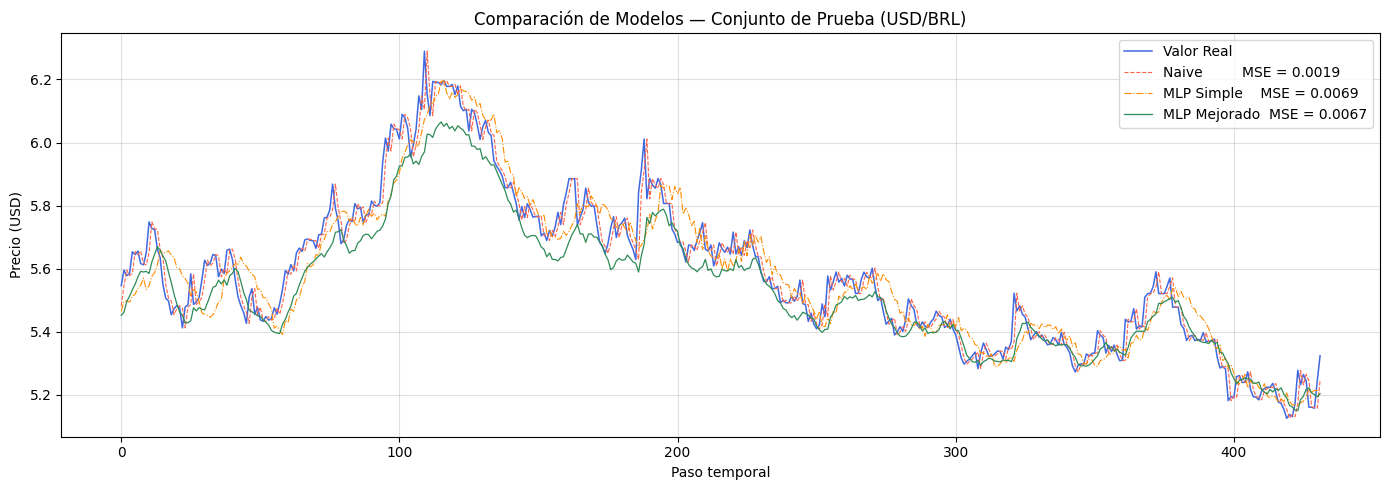

In [42]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_real,             label='Valor Real',                                    color='royalblue',  linewidth=1.1)
plt.plot(y_pred_naive_real,       label=f'Naive         RMSE={rmse_naive:.4f} BRL',      color='tomato',     linewidth=0.8, linestyle='--')
plt.plot(y_pred_simple_real_1d,   label=f'MLP Simple    RMSE={rmse_simple:.4f} BRL',     color='darkorange', linewidth=0.8, linestyle='-.')
plt.plot(y_pred_mejor_real_1d,    label=f'MLP Mejorado  RMSE={rmse_mejor:.4f} BRL',      color='seagreen',   linewidth=0.9)
plt.title('Comparación de Modelos — Conjunto de Prueba (USD/BRL)')
plt.xlabel('Paso temporal')
plt.ylabel('Precio (BRL)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 9. Conclusiones y Trabajo Futuro

### Interpretación de Resultados
* **Modelo Naive:** Fuerte línea base. En finanzas, "el precio de hoy" es un predictor muy robusto por la alta autocorrelación.
* **MLP Simple:** Rendimiento limitado a las dependencias estrictamente lineales de los últimos 50 días.
* **MLP Profundo:** Captura patrones complejos (no lineales). El uso de *Dropout* evitó la memorización (sobreajuste).

### Limitación Principal
* **Falta de memoria temporal:** El MLP trata los 50 días como un vector estático; no procesa el **orden secuencial** de los datos, dificultando las dependencias a largo plazo.

### Líneas de Mejora
* **Datos:** Ampliar la ventana de tiempo (`> 50 días`) y añadir variables exógenas (medias móviles, volatilidad, etc.).
* **Modelos:** Implementar arquitecturas recurrentes (**LSTM o GRU**), diseñadas específicamente para secuencias temporales.
* **Optimización:** Usar un *scheduler* para la tasa de aprendizaje.